In [ ]:
!unzip "Alat Tulis.zip"

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "Alat Tulis",
    image_size=(224,224),
    batch_size=32
)

Found 300 files belonging to 4 classes.


In [ ]:
class_names = dataset.class_names
print(class_names)

['Buku', 'Penghapus', 'Pensil', 'Pulpen']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

dataset = dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
dataset_size = len(dataset)

train_size = int(0.8 * dataset_size)

train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)

print("Training Batch:", len(train_dataset))
print("Testing Batch:", len(test_dataset))

Training Batch: 8
Testing Batch: 2


In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(4,activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.2344 - loss: 2.3174 - val_accuracy: 0.1818 - val_loss: 1.3883
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.3359 - loss: 1.3714 - val_accuracy: 0.5227 - val_loss: 1.3039
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.3711 - loss: 1.3155 - val_accuracy: 0.3409 - val_loss: 1.2578
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.4805 - loss: 1.1509 - val_accuracy: 0.5682 - val_loss: 1.1210
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.6016 - loss: 1.0416 - val_accuracy: 0.6591 - val_loss: 0.8859
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.6055 - loss: 0.9631 - val_accuracy: 0.5909 - val_loss: 0.8909
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.7227 - loss: 0.7113 - val_accuracy: 0.5909 - val_loss: 1.1355
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.7578 - loss: 0.6944 - val_accuracy: 0.7045 - val_loss: 0.6561
Epoch 9/

In [ ]:
loss, accuracy = model.evaluate(test_dataset)

print("Accuracy :", accuracy)

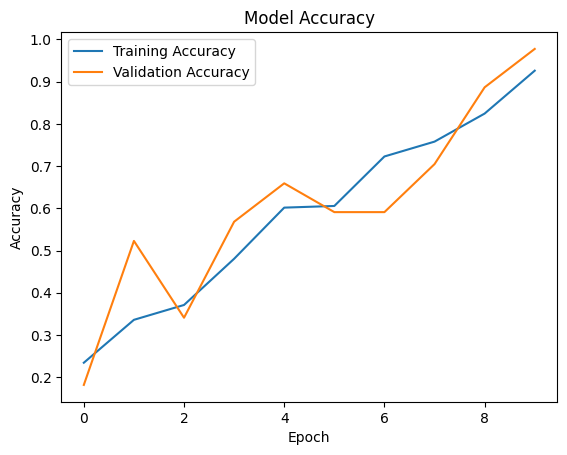

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy','Validation Accuracy'])

plt.show()

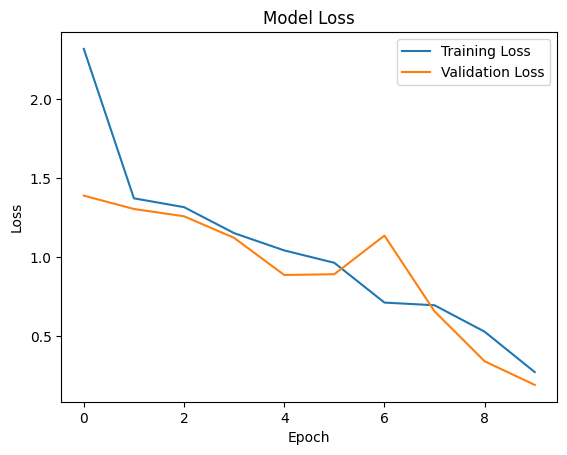

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_dataset)

print("Accuracy:", accuracy)
print("Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 1.0000 - loss: 0.1234
Accuracy: 1.0
Loss: 0.12337742000818253


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    pred = model.predict(images)
    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


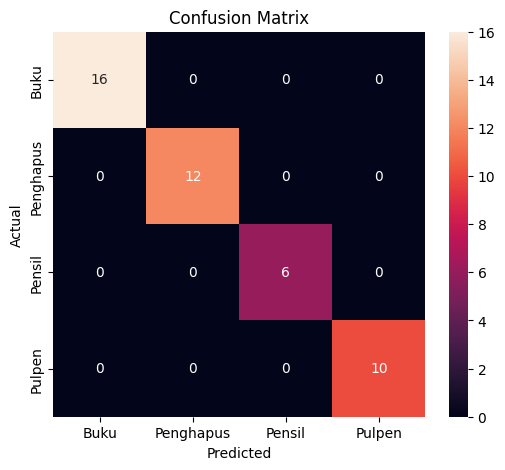

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.save("model_alat_tulis.h5")

In [ ]:
import os

print(os.listdir())

['.config', 'model_alat_tulis.h5', 'Alat Tulis', 'Alat Tulis.zip', 'sample_data']


In [ ]:
from google.colab import files

files.download("model_alat_tulis.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>